In [6]:
# libraries
import pandas as pd
from tensorflow.keras.models import Sequential  
from tensorflow.keras.layers import Dense,BatchNormalization,Dropout
from sklearn.model_selection import train_test_split
from  sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt


In [7]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
# data loading 
df=pd.read_csv("Churn_Modelling.csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
# drop useless columns
df.drop(columns=['RowNumber','CustomerId','Surname','Geography'],inplace=True)

In [10]:
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Female,43,2,125510.82,1,1,1,79084.10,0


In [11]:
# handling categorical columns 
df['Gender']=df['Gender'].map({'Male':0,'Female':1})
df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,1,42,2,0.00,1,1,1,101348.88,1
1,608,1,41,1,83807.86,1,0,1,112542.58,0
2,502,1,42,8,159660.80,3,1,0,113931.57,1
3,699,1,39,1,0.00,2,0,0,93826.63,0
4,850,1,43,2,125510.82,1,1,1,79084.10,0


In [12]:
# feature selection
x=df.drop(columns=["Exited"])
y=df["Exited"]


In [14]:
x_train,x_test,y_train,y=test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
# ann architecture
model=Sequential()

# layer 1
model.add(Dense(512,activation='relu',input_dim=(9)))
model.add(Dropout(0.1))

# layer 2
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.1))

# layer 3
model.add(Dense(128,activation='relu'))
model.add(Dropout(0.1))

# layer 4
model.add(Dense(64,activation='relu'))

# output layer
model.add(Dense(1,activation='sigmoid')) 

# to find the  trainaable parameters
model.summary()

c:\Users\kalash\Downloads\ANN\venv\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 512)            │         5,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 177,665 (694.00 KB)

 Trainable params: 177,665 (694.00 KB)

 Non-trainable params: 0 (0.00 B)

In [26]:
model.get_weights()

[array([[-0.01233608, -0.06635542, -0.02584682, ...,  0.10610609,
         -0.02722615, -0.08822365],
        [ 0.03327736, -0.05449615,  0.09198992, ...,  0.05419916,
         -0.10729327, -0.06850715],
        [-0.00206551,  0.04303542, -0.05705915, ...,  0.07424502,
         -0.03988302,  0.03364529],
        ...,
        [-0.05291972, -0.0641287 , -0.05584938, ...,  0.05621594,
          0.01837721,  0.0495239 ],
        [-0.07384133,  0.00205857, -0.00184519, ...,  0.07366773,
          0.00322843, -0.08085746],
        [-0.0409067 , -0.10190178,  0.07884139, ..., -0.0502997 ,
         -0.05507797, -0.00311431]], shape=(9, 512), dtype=float32),
 array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0.

In [27]:
# model complie
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [32]:
# model fitting
history=model.fit(x_train,y_train,epochs=145,batch_size=32,validation_split=0.2)

Epoch 1/145
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7931 - loss: 0.5100 - val_accuracy: 0.7987 - val_loss: 0.5023
Epoch 2/145
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7934 - loss: 0.5095 - val_accuracy: 0.7987 - val_loss: 0.5023
Epoch 3/145
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7933 - loss: 0.5096 - val_accuracy: 0.7987 - val_loss: 0.5024
Epoch 4/145
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7934 - loss: 0.5095 - val_accuracy: 0.7987 - val_loss: 0.5024
Epoch 5/145
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7934 - loss: 0.5094 - val_accuracy: 0.7987 - val_loss: 0.5021
Epoch 6/145
200/200 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7934 - loss: 0.6627 - val_accuracy: 0.7987 - val_loss: 0.5023
Epoch 7/145
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7934 - loss: 0.5095 - val_accuracy: 0.7987 - val_loss: 0.5021
Epoch 8/145
200/200 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.7934 - loss: 0.5095 - val_accu

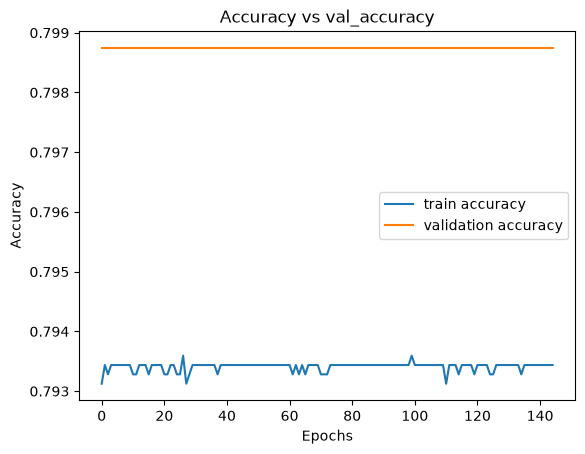

In [33]:
# accuracy graph
plt.plot(history.history['accuracy'],label='train accuracy')
plt.plot(history.history['val_accuracy'],label='validation accuracy')
plt.title('Accuracy vs val_accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

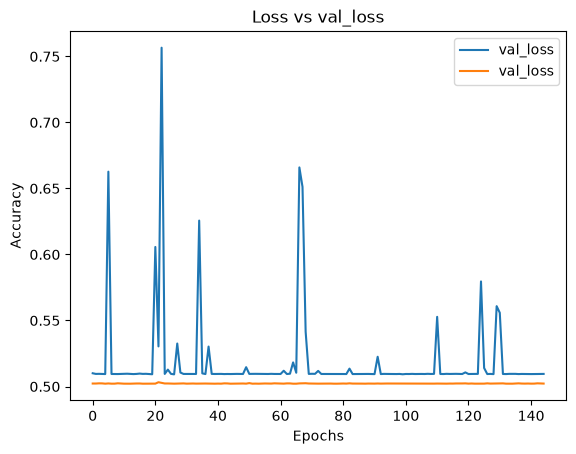

In [34]:
# loss graph
plt.plot(history.history['loss'],label='val_loss')
plt.plot(history.history['val_loss'],label='val_loss')
plt.title('Loss vs val_loss')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

In [ ]:
# how to prevent model overfitting
#1 dropout
# batch normalization
# weight initialization
# regularization
# epochs increase
# layers add
# nodes increase 
# activation change
# optimizers change
# data argumentation 
# keras tuning
